# ZimaBlue — a tour

Build a pool, put a cleaner in it, make it dirty, run it, then look at what
happened. Every number below is computed when you run this notebook.

```bash
pip install "zimablue[viz]"
```

In [1]:
%matplotlib inline

import os

import matplotlib.pyplot as plt
import numpy as np

import zimablue as zb

# Every run in this notebook is scaled by this. Two minutes keeps the tour
# quick; raise it to 20 or 30 to see controllers actually finish a pool.
MINUTES = float(os.environ.get("ZIMABLUE_TOUR_MINUTES", 6))

print("zimablue", zb.__version__, "·", MINUTES, "simulated minutes per run")

zimablue 0.1.0 · 6.0 simulated minutes per run


## Build a pool

A pool is a boundary polygon, a depth model, a surface material and some
features. The presets are functions that put those four things together.

In [2]:
pool = zb.make_pool("kidney")

print(pool)
print(f"  navigable floor  {pool.floor_area:6.1f} m2")
print(f"  wetted walls     {pool.wall_area:6.1f} m2")
print(f"  depth            {pool.max_depth:6.1f} m at the deepest point")
print(f"  presets          {', '.join(zb.POOL_PRESETS.names())}")

Pool(name='kidney', floor_area=54.8 m2, max_depth=2.00 m, features=4)
  navigable floor    54.8 m2
  wetted walls       48.2 m2
  depth               2.0 m at the deepest point
  presets          kidney, l_shaped, oval, rectangular, sloped, stairs


### Look at it

`zb.preview` draws the pool in the browser. Drag to rotate, scroll to zoom,
shift-drag to pan, double-click to reset. There are no widget extensions and no
kernel round trip, so it still works in an exported HTML file.

Vertical scale is exaggerated 2.6×. A 12 m pool 2 m deep is otherwise a pancake.

In [3]:
zb.preview(pool)

### Or build your own

The presets have no special status. Hand it a Shapely polygon and a depth model
and you have a pool; register it and the name works anywhere a preset name
does, including `zimablue run` and scenario YAML.

In [4]:
from shapely.geometry import box as shapely_box

lap = zb.Pool(
    boundary=shapely_box(0, 0, 14, 6),
    depth=zb.PlaneSlopeDepth(
        shallow=0.9, deep=2.4, origin=(0.0, 0.0), direction=(1.0, 0.0), length=14.0
    ),
    name="lap_pool",
    material="tile",
    features=(
        zb.Obstacle("planter", polygon=shapely_box(8.0, 2.4, 9.2, 3.6), height=0.9),
        zb.Drain("main", position=(12.0, 3.0), radius=0.3, flow_rate=0.2),
        zb.Return("jet", position=(0.5, 3.0), direction=(1.0, 0.0)),
    ),
)
zb.POOL_PRESETS.add("lap_pool", lambda: lap)

zb.preview(lap)

## Add a cleaner

Cleaners are built from components. To widen the brush you construct a
different `Brush`; there is no `WideBrushCleaner` to subclass.

In [5]:
robot = zb.Cleaner(
    chassis=zb.Chassis(length=0.45, mass=10.5),
    cleaning=zb.CleaningSystem(
        brush=zb.Brush(width=0.38, aggressiveness=1.2),
        filter=zb.Filter(capacity=1200.0, mesh=45e-6),
    ),
    sensors=[zb.Encoder(), zb.IMU(), zb.Sonar(beam_angles=(0.0, 0.7, -0.7))],
)

print(robot)
print(f"  presets  {', '.join(zb.ROBOT_PRESETS.names())}")

Cleaner(name='cleaner', sensors=['encoder', 'imu', 'sonar'])
  presets  compact, heavy_duty, tracked


Sensors are imperfect on purpose, and you can break one on purpose too.

In [6]:
robot.sensors.sonar.inject_fault(
    bias=0.15,  # reads 15 cm long
    dropout_probability=0.02,  # loses 2% of pings
    start_time=120.0,  # ...starting two minutes in
)
print(robot.sensors.sonar)

Sonar(name='sonar', rate=20.0 Hz)


## Make it dirty

Dirt has a location. Sediment and algae live in continuous rasters; leaves and
twigs are discrete items, and some of them are too big for the intake to
swallow.

Settling velocity comes from the Ferguson–Church equation, so the numbers below
can be checked against the sediment literature.

In [7]:
spec = zb.make_dirt("autumn")
state = spec.build(pool, np.random.default_rng(0))

print(f"total dirt   {state.total_mass:8.1f} g")
print(f"debris items {len(state.debris):8d}")
print()
print(f"{'type':<12}{'mass (g)':>10}{'grain (um)':>12}{'settling (mm/s)':>18}{'adhesion':>10}")
for name in state.field.layer_names():
    kind = state.field.types[name]
    mass = float(state.field.layers[name].sum())
    print(
        f"{name:<12}{mass:>10.1f}{kind.particle_size * 1e6:>12.0f}"
        f"{kind.settling_velocity * 1e3:>18.1f}{kind.adhesion:>10.2f}"
    )

total dirt      986.7 g
debris items       60

type          mass (g)  grain (um)   settling (mm/s)  adhesion
algae            274.0          15               0.0      0.85
sediment         493.3          20               0.1      0.10


## Run it

A simulation is a pool, a robot, some dirt, a controller and a seed.

In [8]:
result = zb.Simulation(
    pool="kidney", robot="tracked", dirt="autumn", controller="baseline_coverage", seed=42
).run(minutes=MINUTES)

print(result.metrics.summary())

  coverage            33.0 %   (walls 19 %)
  dirt removed        12.7 %   (127 g of 1002 g)
  uniformity          52.3 %
  revisits            0.47   extra passes/cell
  distance            78.2 m
  runtime              6.0 min
  energy               6.6 Wh   (battery 94 % left)
  collisions            75
  stuck                  0 events, 0.0 s
  termination       duration


### Where the dirt actually went

The summary numbers hide the geography. The spatial metrics keep it: which
cells were visited, how often, and how much dirt each one still holds.

In [9]:
spatial = result.spatial
navigable = spatial.navigable
grid = pool.grid()  # the raster the metrics were computed on
cell_area = grid.cell_area

driven_over = navigable & (spatial.visits > 0)
threshold = 0.2 * spatial.initial_dirt.max()
still_dirty = driven_over & (spatial.remaining_dirt > threshold)

print(f"never visited            {(navigable & (spatial.visits == 0)).sum() * cell_area:6.1f} m2")
print(f"visited once             {(navigable & (spatial.visits == 1)).sum() * cell_area:6.1f} m2")
print(f"visited five times or more{(navigable & (spatial.visits >= 5)).sum() * cell_area:5.1f} m2")
print()
print(f"driven over but still dirty  {still_dirty.sum() * cell_area:6.1f} m2")
print("(suction alone does not lift adhered dirt -- it takes brush passes)")

never visited              36.8 m2
visited once               12.6 m2
visited five times or more  0.2 m2

driven over but still dirty     1.9 m2
(suction alone does not lift adhered dirt -- it takes brush passes)


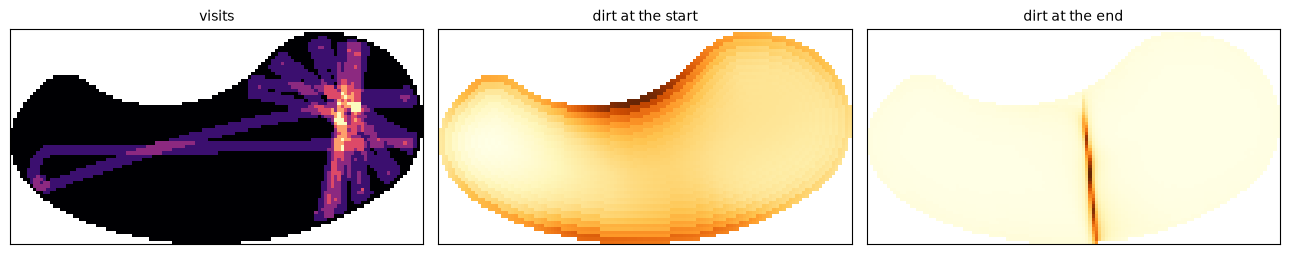

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
extent = grid.extent

for ax, (field, title, cmap) in zip(
    axes,
    [
        (np.where(navigable, spatial.visits, np.nan), "visits", "magma"),
        (np.where(navigable, spatial.initial_dirt, np.nan), "dirt at the start", "YlOrBr"),
        (np.where(navigable, spatial.remaining_dirt, np.nan), "dirt at the end", "YlOrBr"),
    ],
    strict=True,
):
    # Nearest, never bilinear: a blur here paints coverage the robot never had.
    ax.imshow(field, origin="lower", extent=extent, cmap=cmap, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

## Coverage is not cleanliness

Race a few controllers and the ranking flips depending on which number you
report.

The two oracles make it obvious, and neither is deployable -- both read ground
truth. `lawnmower_oracle` drives a perfect path and turns out to be a poor
cleaner. `dirt_oracle` drives at whatever is dirtiest and barely covers a
tenth of the pool. Each is the best thing here at one of the two numbers.

In [11]:
rows = []
for name in ["lawnmower_oracle", "dirt_oracle", "random_bounce", "baseline_coverage", "systematic"]:
    # Ground truth is off unless you ask for it, and only the oracles need it
    # -- so nobody reaches for it by accident.
    run = zb.Simulation(
        pool="kidney",
        dirt="autumn",
        controller=name,
        seed=42,
        expose_truth=name.endswith("oracle"),
    ).run(minutes=MINUTES)
    rows.append(
        (
            name,
            run.metrics.coverage,
            run.metrics.dirt_removed_fraction,
            run.metrics.distance_traveled,
        )
    )

print(f"{'controller':<20}{'coverage':>10}{'dirt removed':>14}{'distance':>11}")
for name, coverage, dirt, distance in rows:
    print(f"{name:<20}{coverage:>9.1%}{dirt:>14.1%}{distance:>10.0f} m")

best_coverage = max(rows, key=lambda r: r[1])[0]
best_cleaning = max(rows, key=lambda r: r[2])[0]
print()
print(f"best coverage: {best_coverage}   \u00b7   best cleaning: {best_cleaning}")
if best_coverage == best_cleaning:
    print(f"Both to {best_coverage} this time. It happens; try raising MINUTES.")
else:
    print("Two different controllers. Report one number and you rank them wrong.")

controller            coverage  dirt removed   distance
lawnmower_oracle        46.1%         19.7%        92 m
dirt_oracle             11.2%         34.7%        51 m
random_bounce           37.3%         14.9%        79 m
baseline_coverage       33.0%         12.7%        78 m
systematic              31.0%         14.3%        82 m

best coverage: lawnmower_oracle   ·   best cleaning: dirt_oracle
Two different controllers. Report one number and you rank them wrong.


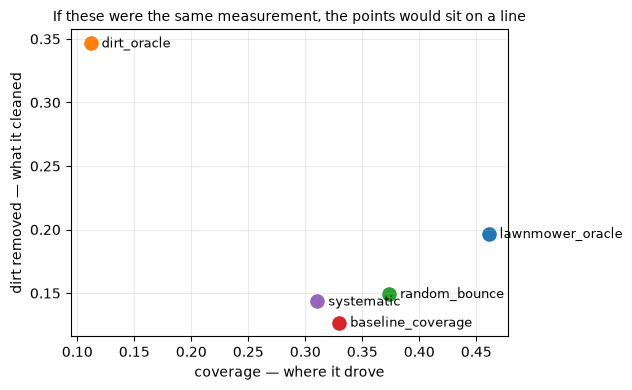

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for name, coverage, dirt, _ in rows:
    ax.scatter(coverage, dirt, s=90)
    ax.annotate(name, (coverage, dirt), textcoords="offset points", xytext=(8, -3), fontsize=9)
ax.set_xlabel("coverage — where it drove")
ax.set_ylabel("dirt removed — what it cleaned")
ax.set_title("If these were the same measurement, the points would sit on a line", fontsize=10)
ax.grid(alpha=0.25)
fig.tight_layout()

## Watch it

A recording carries its own pool geometry and robot configuration, so it
replays from the file alone. You do not need the code that produced it, and it
does not matter if the presets have changed since.

In [13]:
from pathlib import Path

path = result.save(Path("runs") / "tour.zbr")
recording = result.recording

print(recording.describe())

format          zbr v1
zimablue        0.1.0
scenario        adhoc
seed            42
pool            kidney
robot           tracked
dirt            autumn
controller      baseline_coverage
timestep        0.02 s
frames          18000 (6.0 min)
channels        42
events          118
dirt keyframes  37


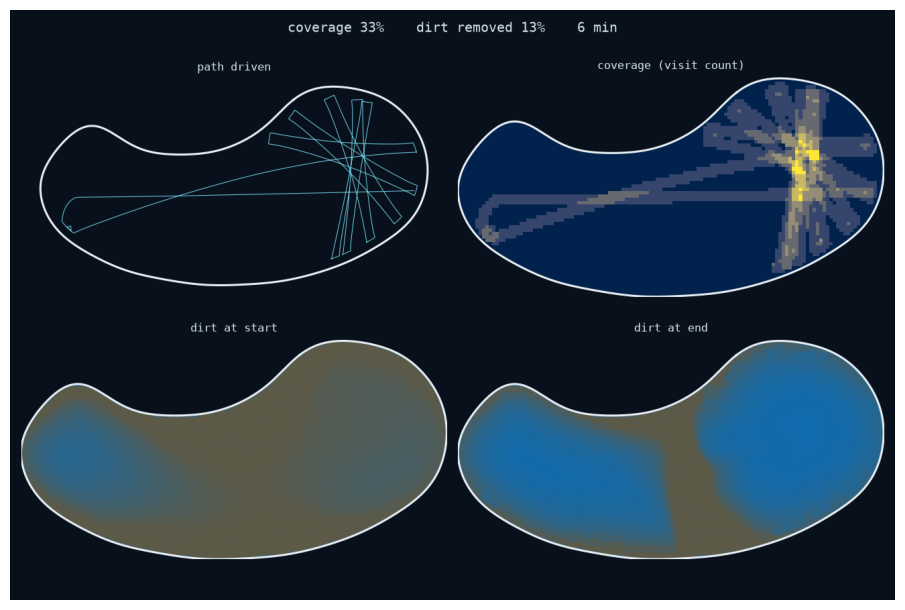

In [14]:
from zimablue.replay import export_summary

summary = export_summary(recording, "runs/tour_summary.png")

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.imshow(plt.imread(summary))
ax.set_axis_off()
fig.tight_layout()

### The pool you just cleaned

Hand the finished run to `preview` and it tints the floor with the dirt left
behind and draws the path that was driven. Turning it over is the quickest way
to see why a corner scored badly.

In [15]:
zb.preview(result)

### In 3D

This renders in 3D; it does not simulate in 3D. The motion still comes from the
2D backend. The geometry is real, though: the floor is a surface sampled from
the depth model, so the robot sits lower at the deep end because the pool is
deeper there.

<Axes3D: title={'center': 'adhoc   06:00   17% of the dirt   78 m driven'}>

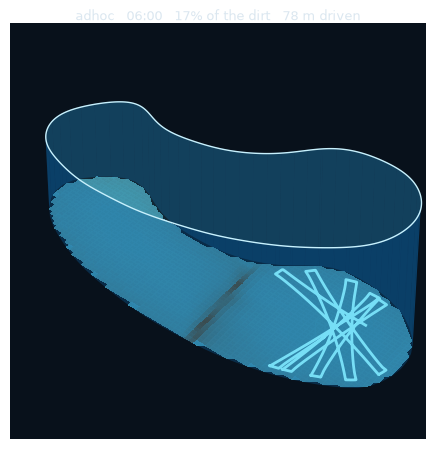

In [16]:
from zimablue.replay import render_3d

fig = plt.figure(figsize=(9, 5.4))
ax = fig.add_subplot(111, projection="3d")
render_3d(recording, recording.n_frames - 1, ax=ax)

### Dirt cam

Top-down replay is calming. From the cleaner's own bumper it is not — the
camera sits 18 cm off the floor and the pool turns out to be a silt plain with
leaves in it.

Same recording, same dirt field, drawn by inverse perspective mapping: one
NumPy expression per frame over a grid of rays, no 3D engine. From above you
see where the robot went. From down here you see what it left behind.

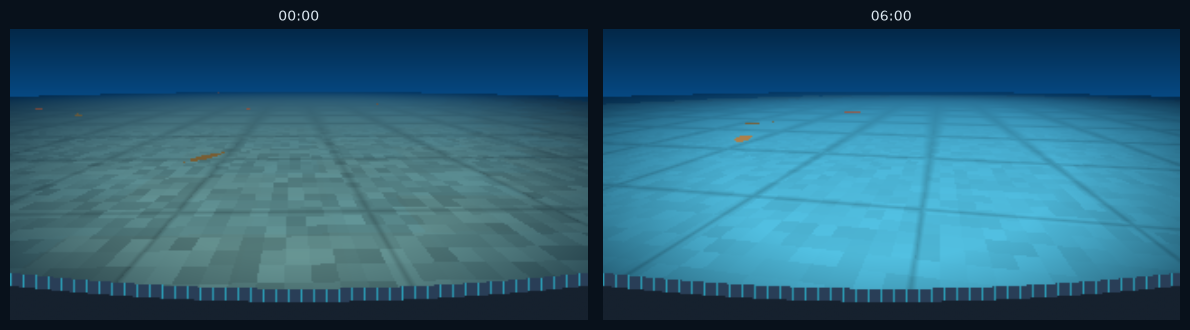

In [17]:
from zimablue.replay import DirtCam

cam = DirtCam(recording)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), facecolor="#08111b")
for ax, index in zip(axes, [0, recording.n_frames - 1], strict=True):
    seconds = float(recording.frames["time"][index])
    ax.imshow(cam.frame(index), interpolation="bilinear", aspect="auto")
    ax.set_title(f"{int(seconds // 60):02d}:{int(seconds % 60):02d}", color="#dbe7f0", fontsize=10)
    ax.set_axis_off()
fig.tight_layout()

Rendering the whole run as an animation, with the top-down panel beside it:

```python
from zimablue.replay import export_dirtcam
export_dirtcam(recording, "runs/tour_dirtcam.gif")
```

or from a shell, without opening Python at all:

```bash
zimablue replay runs/tour.zbr --dirtcam --gif dirtcam.gif
```

## Estimate it

The `systematic` controller is not told where it is. It runs an EKF over
position, heading and **gyro bias**, and builds an occupancy map from sonar as
it goes.

Bias is only observable when the robot stops, because a stationary gyro reads
its own bias. Zero-velocity updates are what stop the heading fanning out over
half an hour. The plot below is what having no absolute reference costs you.

gyro bias settled at +0.28 deg/s


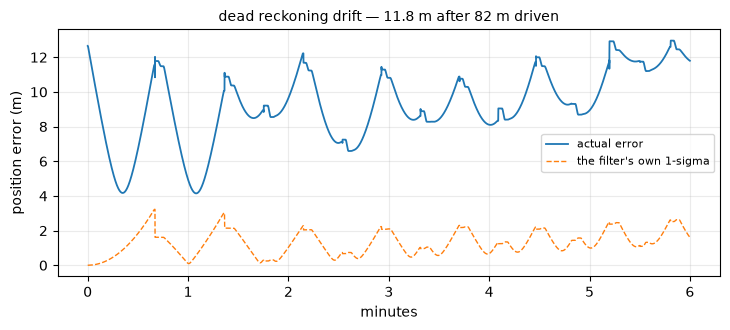

In [18]:
estimated = zb.Simulation(pool="kidney", dirt="autumn", controller="systematic", seed=42).run(
    minutes=MINUTES
)

# A controller can publish channels of its own; they land under "ctl.".
frames = estimated.recording.frames
error = np.hypot(frames["ctl.est_x"] - frames["x"], frames["ctl.est_y"] - frames["y"])
sigma = frames["ctl.est_sigma"]

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(frames["time"] / 60.0, error, linewidth=1.3, label="actual error")
ax.plot(
    frames["time"] / 60.0, sigma, linewidth=1.0, linestyle="--", label="the filter's own 1-sigma"
)
ax.set_xlabel("minutes")
ax.set_ylabel("position error (m)")
ax.set_title(
    f"dead reckoning drift — {error[-1]:.1f} m after {frames['distance'][-1]:.0f} m driven",
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()

print(f"gyro bias settled at {np.degrees(frames['ctl.est_bias'][-1]):+.2f} deg/s")

## Scale it

One run tells you what happened once. A controller that scores 80% on seed 42
and 45% on seed 43 has been sampled, not measured. Run a batch and report the
spread.

In [19]:
from zimablue.batch import run_batch

scenario = zb.load_scenario("kidney")
scenario.duration = MINUTES * 60.0

batch = run_batch(scenario, episodes=8)
print(batch.summary())

coverage = batch.values("coverage")
print()
print(
    f"coverage ranged {min(coverage):.1%} to {max(coverage):.1%}"
    f"  (spread {max(coverage) - min(coverage):.1%})"
)
print(
    f"the worst episode was seed {batch.worst('coverage', count=1)[0].seed}"
    " -- re-runnable exactly, from the seed alone"
)

episodes           8
success_rate       100.0 %
mean_coverage      35.8 %  (sd 2.1, min 32.5, max 38.2)
mean_dirt_removed  22.0 %  (sd 7.5, min 13.9, max 37.1)
mean_runtime       6.0 min
mean_energy        6.6 Wh
stuck_rate         0.0 %
mean_collisions    82
worst_episode      seed 48 (32.5 % coverage)

coverage ranged 32.5% to 38.2%  (spread 5.7%)
the worst episode was seed 48 -- re-runnable exactly, from the seed alone


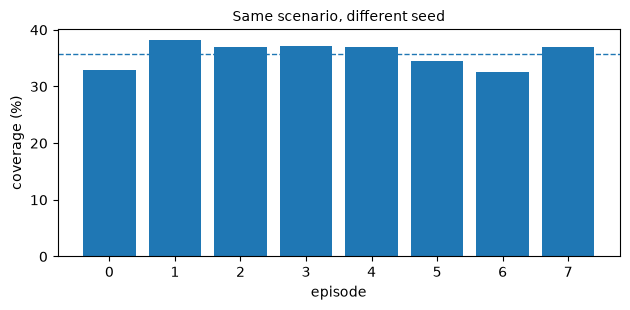

In [20]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(range(len(coverage)), [c * 100 for c in coverage])
ax.axhline(np.mean(coverage) * 100, linestyle="--", linewidth=1)
ax.set_xlabel("episode")
ax.set_ylabel("coverage (%)")
ax.set_title("Same scenario, different seed", fontsize=10)
fig.tight_layout()

## Extend it

A controller is a class with `reset` and `step`. It sees sensor readings and
never ground truth. Register it and it works from scenario YAML and the CLI
like any built-in.

In [21]:
class WallFollower:
    """Hug the right-hand wall at a fixed standoff, using sonar alone."""

    name = "wall_follower"
    STANDOFF = 0.5  # metres of clear floor between the hull and the wall
    CLEARANCE = 0.7  # metres ahead before committing to a turn

    def reset(self, robot):
        self.top = robot.locomotion.max_speed
        self.turning_until = 0.0

    def step(self, control_input):
        # Sensor readings, the clock, and the robot's own spec. There is no
        # pose in here, which is the whole point of the interface.
        sonar = control_input.reading("sonar")
        contact = control_input.reading("contact")
        bumped = bool(contact and contact.valid and np.any(contact.values > 0.5))

        if bumped:
            self.turning_until = control_input.time + 1.0
        if control_input.time < self.turning_until:
            return zb.DriveCommand(left=-self.top * 0.5, right=self.top * 0.5, brush=1.0, pump=1.0)

        if sonar is None or not sonar.valid:
            # A dropped ping is not an emergency: hold course.
            return zb.DriveCommand(left=self.top * 0.6, right=self.top * 0.6, brush=1.0, pump=1.0)

        ahead, _left, right = (float(v) for v in sonar.values[:3])
        if ahead < self.CLEARANCE:
            return zb.DriveCommand(left=-self.top * 0.4, right=self.top * 0.4, brush=1.0, pump=1.0)

        # The side beam sits 40 degrees off the bow, so its range is a slant,
        # not a standoff. Steering on the raw range holds the robot at
        # 0.64 x the distance you asked for -- which is close enough to scrape.
        beam = control_input.robot.sensors.sonar.beam_angles[2]
        standoff = right * abs(np.sin(beam))

        turn = float(np.clip((self.STANDOFF - standoff) * 1.2, -0.45, 0.45))
        speed = self.top * 0.55
        return zb.DriveCommand(
            left=speed * (1 - turn), right=speed * (1 + turn), brush=1.0, pump=1.0
        )


zb.CONTROLLERS.add("wall_follower", WallFollower)

follower = zb.Simulation(pool="kidney", dirt="autumn", controller="wall_follower", seed=42).run(
    minutes=MINUTES
)
print(follower.metrics.summary())

  coverage            18.7 %   (walls 8 %)
  dirt removed        14.4 %   (144 g of 1002 g)
  uniformity          54.6 %
  revisits            1.05   extra passes/cell
  distance            61.0 m
  runtime              6.0 min
  energy               6.5 Wh   (battery 95 % left)
  collisions             0
  stuck                  0 events, 0.0 s
  termination       duration


Look at what that bought. A wall follower reaches the perimeter and nothing
else, so it covers very little while hardly ever bumping into anything. Real
cleaners make that trade, and a testbed should show it to you.

## Determinism

Run the same version on the same platform, with the same scenario and seed, and
you get the exact same run every time. Here it is, checked.

In [22]:
a = zb.Simulation(pool="kidney", dirt="autumn", seed=7, record=False).run(minutes=1)
b = zb.Simulation(pool="kidney", dirt="autumn", seed=7, record=False).run(minutes=1)
c = zb.Simulation(pool="kidney", dirt="autumn", seed=8, record=False).run(minutes=1)

print(f"seed 7 twice:  coverage {a.metrics.coverage:.10%} vs {b.metrics.coverage:.10%}")
print(f"seed 8:        coverage {c.metrics.coverage:.10%}")
assert a.metrics.coverage == b.metrics.coverage, "determinism contract violated"
assert a.metrics.coverage != c.metrics.coverage, "the seed should change the outcome"
print("\nidentical on the same seed, different on another")

seed 7 twice:  coverage 8.6964448496% vs 8.6964448496%
seed 8:        coverage 8.7511394713%

identical on the same seed, different on another


## Where to go next

| | |
|---|---|
| [Getting started](../docs/getting-started.md) | Install, first run, common tasks |
| [Architecture](../docs/architecture.md) | Layering, backends, determinism contract |
| [Research](../docs/research.md) | Prior art, and which decision each finding drove |
| [Scenarios](../docs/scenarios.md) | YAML experiments and batch sweeps |
| [Recording](../docs/recording.md) | The `.zbr` format, channel by channel |
| [Replay](../docs/replay.md) | Controls, exporters, rendering notes |
| [Roadmap](../docs/roadmap.md) | Done, next, and deliberately not planned |

The scripts in `examples/` cover the same ground one topic at a time, and each
takes `--minutes` if you want a shorter run.